## Modelado y evualación

Este notebook se ha estructurado para abordar el modelado predictivo del `Churn` del cliente, comenzando desde la preparación de los datos hasta la evaluación exhaustiva de los modelos. Es crucial la aplicación correcta de técnicas de preprocesamiento y balanceo de clases para garantizar la validez de los resultados. La separación de este proceso del EDA (Exploratory Data Analysis) en un notebook distinto asegura un enfoque claro y una metodología robusta para la construcción de modelos de Machine Learning.

### Nota importante sobre el flujo de trabajo

La limpieza y el análisis exploratorio se realizaron en el notebook de EDA.

Aquí, en el notebook de modelado, sí corresponde aplicar:
- `train_test_split`
- `OneHotEncoder` para variables categóricas
- `StandardScaler` para variables numéricas
- `ColumnTransformer` y `Pipeline` para evitar fuga de datos

Este es el punto correcto para el preprocesamiento del modelo.

### 1. Carga de Librerías y Datos

Esta sección se dedica a la configuración inicial del entorno de trabajo. Se importan todas las librerías necesarias de Python que se utilizarán a lo largo del notebook para la manipulación de datos, preprocesamiento, construcción de modelos de aprendizaje automático y evaluación de su rendimiento. Además, se carga el conjunto de datos `teleco_clean.csv` en un DataFrame de pandas para su posterior procesamiento y análisis. Es crucial asegurar que todas las herramientas estén disponibles y que los datos estén correctamente cargados para proceder con el modelado.

In [42]:
import importlib
import pandas as pd
import numpy as np

from sklearn.model_selection import train_test_split, GridSearchCV
from sklearn.preprocessing import StandardScaler, OneHotEncoder
from sklearn.compose import ColumnTransformer
from sklearn.pipeline import Pipeline
from sklearn.metrics import accuracy_score, precision_score, recall_score, f1_score, roc_auc_score, confusion_matrix, ConfusionMatrixDisplay

from sklearn.linear_model import LogisticRegression
from sklearn.ensemble import RandomForestClassifier, GradientBoostingClassifier
from sklearn.svm import SVC

import joblib
import matplotlib.pyplot as plt
plt = importlib.reload(plt)
import seaborn as sns
from pathlib import Path

# Carpeta común para evidencias
IMAGES_DIR = Path('../images')
IMAGES_DIR.mkdir(parents=True, exist_ok=True)

# Cargar el conjunto de datos
df = pd.read_csv('../data/processed/teleco_clean.csv')

# Mostrar las primeras filas e información básica para confirmar la carga
print("Dataset cargado exitosamente. Primeras 5 filas:")
display(df.head())
print("\nInformación del dataset:")
df.info()

Dataset cargado exitosamente. Primeras 5 filas:


,gender,SeniorCitizen,Partner,Dependents,tenure,PhoneService,MultipleLines,InternetService,OnlineSecurity,OnlineBackup,DeviceProtection,TechSupport,StreamingTV,StreamingMovies,Contract,PaperlessBilling,PaymentMethod,MonthlyCharges,TotalCharges,Churn
0,Female,0,Yes,No,1,No,No phone service,DSL,No,Yes,No,No,No,No,Month-to-month,Yes,Electronic check,29.85,29.85,No
1,Male,0,No,No,34,Yes,No,DSL,Yes,No,Yes,No,No,No,One year,No,Mailed check,56.95,1889.50,No
2,Male,0,No,No,2,Yes,No,DSL,Yes,Yes,No,No,No,No,Month-to-month,Yes,Mailed check,53.85,108.15,Yes
3,Male,0,No,No,45,No,No phone service,DSL,Yes,No,Yes,Yes,No,No,One year,No,Bank transfer (automatic),42.30,1840.75,No
4,Female,0,No,No,2,Yes,No,Fiber optic,No,No,No,No,No,No,Month-to-month,Yes,Electronic check,70.70,151.65,Yes



Información del dataset:
<class 'pandas.DataFrame'>
RangeIndex: 7021 entries, 0 to 7020
Data columns (total 20 columns):
 #   Column            Non-Null Count  Dtype  
---  ------            --------------  -----  
 0   gender            7021 non-null   str    
 1   SeniorCitizen     7021 non-null   int64  
 2   Partner           7021 non-null   str    
 3   Dependents        7021 non-null   str    
 4   tenure            7021 non-null   int64  
 5   PhoneService      7021 non-null   str    
 6   MultipleLines     7021 non-null   str    
 7   InternetService   7021 non-null   str    
 8   OnlineSecurity    7021 non-null   str    
 9   OnlineBackup      7021 non-null   str    
 10  DeviceProtection  7021 non-null   str    
 11  TechSupport       7021 non-null   str    
 12  StreamingTV       7021 non-null   str    
 13  StreamingMovies   7021 non-null   str    
 14  Contract          7021 non-null   str    
 15  PaperlessBilling  7021 non-null   str    
 16  PaymentMethod     7021 non-

#### Conclusión de la Sección 1

La carga del dataset se completó correctamente. El conjunto utilizado para el modelado contiene 7,021 clientes y 20 variables, incluida `Churn`, que indica si el cliente abandonó el servicio. Esta revisión inicial confirma que los datos están disponibles para preparar el entrenamiento y permite conocer el tamaño real del problema antes de construir los modelos.

### 2. Preparación para el Modelado
En esta sección, preparamos el dataset para el entrenamiento de los modelos. La tarea principal es dividir el conjunto de datos en características (X) y la variable objetivo (y), que es `Churn`. Posteriormente, se realiza una división en conjuntos de entrenamiento y prueba utilizando `train_test_split`. Esta separación es fundamental para evaluar la capacidad de generalización de los modelos en datos no vistos y evitar el sobreajuste. También se identifican las características categóricas y numéricas para aplicar el preprocesamiento adecuado en pasos posteriores.

In [43]:
# Separar características (X) y objetivo (y)
X = df.drop('Churn', axis=1)
y = df['Churn'].map({'No': 0, 'Yes': 1}).astype(int)

# Dividir los datos en conjuntos de entrenamiento y prueba (80/20)
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=42, stratify=y)

print(f"X_train shape: {X_train.shape}")
print(f"X_test shape: {X_test.shape}")
print(f"y_train shape: {y_train.shape}")
print(f"y_test shape: {y_test.shape}")

# Identificar características categóricas y numéricas
categorical_features = X.select_dtypes(include=['object', 'bool', 'string', 'category']).columns
numerical_features = X.select_dtypes(include=['int64', 'float64']).columns

print(f"\nCaracterísticas categóricas: {list(categorical_features)}")
print(f"Características numéricas: {list(numerical_features)}")

X_train shape: (5616, 19)
X_test shape: (1405, 19)
y_train shape: (5616,)
y_test shape: (1405,)

Características categóricas: ['gender', 'Partner', 'Dependents', 'PhoneService', 'MultipleLines', 'InternetService', 'OnlineSecurity', 'OnlineBackup', 'DeviceProtection', 'TechSupport', 'StreamingTV', 'StreamingMovies', 'Contract', 'PaperlessBilling', 'PaymentMethod']
Características numéricas: ['SeniorCitizen', 'tenure', 'MonthlyCharges', 'TotalCharges']


#### Conclusión de la Sección 2

Se separaron las características (`X`) de la variable objetivo (`y`) y se codificó `Churn` como 0 para `No` y 1 para `Yes`. Los datos se dividieron en entrenamiento y prueba usando una proporción 80/20 y estratificación, de modo que ambos conjuntos mantienen una proporción comparable de clientes que abandonan y que permanecen. Se identificaron 15 variables categóricas y 4 numéricas, información necesaria para aplicar transformaciones diferentes según el tipo de dato.

### 3. Codificación y Escalado (Análisis y Configuración)

En esta sección, se construye el preprocesador encargado de transformar las características del dataset. Antes de la configuración, realizamos un análisis de la distribución de las variables numéricas (`tenure`, `MonthlyCharges`, `TotalCharges` y `SeniorCitizen`) mediante histogramas y cálculos de asimetría (*skewness*). Este paso es fundamental para seleccionar la técnica de escalado que mejor se adapte a la naturaleza de cada variable.

Este preprocesador se integrará en un `ColumnTransformer`, componente clave del pipeline final para evitar la fuga de datos (*data leakage*) y garantizar la reproducibilidad del modelo.

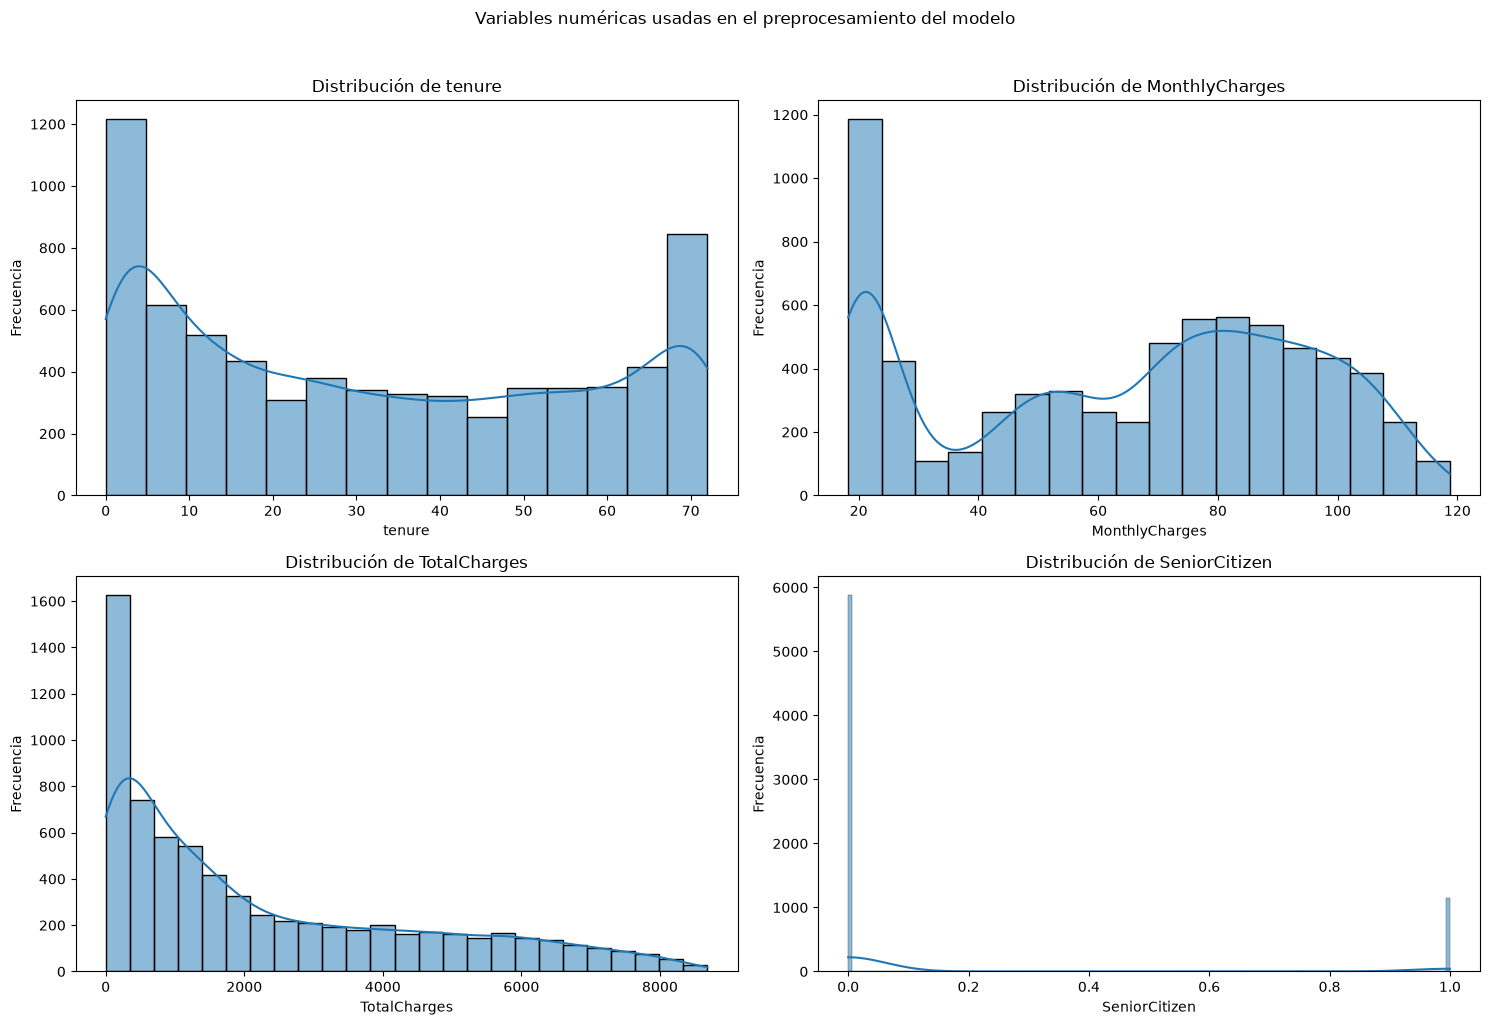


Valores de asimetría:
tenure            0.235542
MonthlyCharges   -0.224097
TotalCharges      0.959910
dtype: float64


In [44]:
import matplotlib.pyplot as plt
import seaborn as sns

# Variables numéricas analizadas previamente en el EDA
numerical_features_to_analyze = ['tenure', 'MonthlyCharges', 'TotalCharges', 'SeniorCitizen']

# Una única figura compuesta para continuar el análisis numérico del EDA
fig, axes = plt.subplots(2, 2, figsize=(15, 10))
for ax, feature in zip(axes.flat, numerical_features_to_analyze):
    sns.histplot(df[feature], kde=True, ax=ax)
    ax.set_title(f'Distribución de {feature}')
    ax.set_xlabel(feature)
    ax.set_ylabel('Frecuencia')

fig.suptitle('Variables numéricas usadas en el preprocesamiento del modelo', y=1.02)
fig.tight_layout()
fig.savefig(IMAGES_DIR / '10_distribuciones_numericas_modelado.png', dpi=300, bbox_inches='tight')
plt.show()

# Calcular la asimetría para apoyar la selección de transformaciones
skewness_values = df[['tenure', 'MonthlyCharges', 'TotalCharges']].skew()
print("\nValores de asimetría:")
print(skewness_values)

In [45]:
from sklearn.preprocessing import PowerTransformer

# Define numerical features for PowerTransformer
tenure_monthlycharges_totalcharges_features = ['tenure', 'MonthlyCharges', 'TotalCharges']

# Define numerical feature for StandardScaler
senior_citizen_feature = ['SeniorCitizen']

# Keep the existing categorical features identified previously
categorical_features = X.select_dtypes(include=['object', 'bool']).columns

# Create an updated preprocessor with PowerTransformer, StandardScaler, and OneHotEncoder
preprocessor = ColumnTransformer(
    transformers=[
        ('power_transform', PowerTransformer(method='yeo-johnson'), tenure_monthlycharges_totalcharges_features),
        ('std_scale', StandardScaler(), senior_citizen_feature),
        ('cat', OneHotEncoder(handle_unknown='ignore'), categorical_features)
    ])

# Display the configuration of the updated preprocessor
print("Updated ColumnTransformer created for preprocessing.")
print(preprocessor)

Updated ColumnTransformer created for preprocessing.
ColumnTransformer(transformers=[('power_transform', PowerTransformer(),
                                 ['tenure', 'MonthlyCharges', 'TotalCharges']),
                                ('std_scale', StandardScaler(),
                                 ['SeniorCitizen']),
                                ('cat', OneHotEncoder(handle_unknown='ignore'),
                                 Index(['gender', 'Partner', 'Dependents', 'PhoneService', 'MultipleLines',
       'InternetService', 'OnlineSecurity', 'OnlineBackup', 'DeviceProtection',
       'TechSupport', 'StreamingTV', 'StreamingMovies', 'Contract',
       'PaperlessBilling', 'PaymentMethod'],
      dtype='str'))])


C:\Users\shein\AppData\Local\Temp\ipykernel_14012\2192803579.py:10: Pandas4Warning: For backward compatibility, 'str' dtypes are included by select_dtypes when 'object' dtype is specified. This behavior is deprecated and will be removed in a future version. Explicitly pass 'str' to `include` to select them, or to `exclude` to remove them and silence this warning.
See https://pandas.pydata.org/docs/user_guide/migration-3-strings.html#string-migration-select-dtypes for details on how to write code that works with pandas 2 and 3.
  categorical_features = X.select_dtypes(include=['object', 'bool']).columns


In [46]:
# Fit and transform X_train using the preprocessor
X_train_transformed = preprocessor.fit_transform(X_train)
X_test_transformed = preprocessor.transform(X_test)

# Get feature names after preprocessing
# Power-transformed features
power_transform_features = tenure_monthlycharges_totalcharges_features

# Standard-scaled features
std_scale_features = senior_citizen_feature

# One-hot encoded features
one_hot_encoder = preprocessor.named_transformers_['cat']
ohe_feature_names = one_hot_encoder.get_feature_names_out(categorical_features)

# Combine all feature names in the correct order
all_transformed_feature_names = list(power_transform_features) + list(std_scale_features) + list(ohe_feature_names)

# Convert transformed arrays back to DataFrames for better readability
X_train_transformed_df = pd.DataFrame(X_train_transformed, columns=all_transformed_feature_names, index=X_train.index)
X_test_transformed_df = pd.DataFrame(X_test_transformed, columns=all_transformed_feature_names, index=X_test.index)

print("X_train_transformed_df shape:", X_train_transformed_df.shape)
print("X_test_transformed_df shape:", X_test_transformed_df.shape)

print("\nPrimeras 5 filas de las variables transformadas (X_train_transformed_df):")
display(X_train_transformed_df.head())

X_train_transformed_df shape: (5616, 45)
X_test_transformed_df shape: (1405, 45)

Primeras 5 filas de las variables transformadas (X_train_transformed_df):


,tenure,MonthlyCharges,TotalCharges,SeniorCitizen,gender_Female,gender_Male,Partner_No,Partner_Yes,Dependents_No,Dependents_Yes,...,StreamingMovies_Yes,Contract_Month-to-month,Contract_One year,Contract_Two year,PaperlessBilling_No,PaperlessBilling_Yes,PaymentMethod_Bank transfer (automatic),PaymentMethod_Credit card (automatic),PaymentMethod_Electronic check,PaymentMethod_Mailed check
2624,-1.504058,0.206583,-1.280887,-0.440315,0.0,1.0,1.0,0.0,1.0,0.0,...,0.0,1.0,0.0,0.0,1.0,0.0,0.0,1.0,0.0,0.0
2645,-0.503938,0.652302,-0.034491,-0.440315,1.0,0.0,1.0,0.0,1.0,0.0,...,0.0,1.0,0.0,0.0,0.0,1.0,0.0,1.0,0.0,0.0
1416,1.227183,0.820922,1.401230,-0.440315,0.0,1.0,0.0,1.0,0.0,1.0,...,1.0,1.0,0.0,0.0,0.0,1.0,1.0,0.0,0.0,0.0
5760,-1.178126,0.038770,-0.869619,-0.440315,0.0,1.0,1.0,0.0,1.0,0.0,...,1.0,1.0,0.0,0.0,0.0,1.0,1.0,0.0,0.0,0.0
2420,-0.002786,-1.498200,-0.645408,-0.440315,0.0,1.0,1.0,0.0,1.0,0.0,...,0.0,1.0,0.0,0.0,0.0,1.0,0.0,0.0,1.0,0.0


#### Conclusión de la Sección 3

El preprocesamiento se configuró de acuerdo con la naturaleza de cada variable. `tenure`, `MonthlyCharges` y `TotalCharges` se transforman con Yeo-Johnson para reducir el efecto de sus distribuciones asimétricas; `SeniorCitizen` se estandariza; y las variables categóricas se convierten mediante One-Hot Encoding. Esta preparación deja los datos en un formato adecuado para los algoritmos y mantiene separadas las decisiones de transformación de la evaluación del modelo.

### 3.1. Manejo del Desbalance de Clases y Elección de Técnica

En esta subsección, abordamos el problema del desbalance de clases en la variable objetivo (`Churn`), donde una clase tiene significativamente menos ejemplos que la otra. Este desbalance puede llevar a que los modelos se sesguen hacia la clase mayoritaria. Para manejar este problema, usaremos smote y balanceo de peso.

#### Justificación de la Elección de SMOTE

Para este caso, se ha seleccionado **SMOTE (Synthetic Minority Over-sampling Technique)** como la técnica principal de sobremuestreo. La elección se basa en que SMOTE es efectiva para generar nuevas muestras sintéticas de la clase minoritaria, lo que ayuda al modelo a aprender patrones más robustos sin simplemente duplicar datos (evitando sobreajuste). Además, al optar por el sobremuestreo, buscamos retener la mayor cantidad de información posible de la clase mayoritaria, que podría perderse con el submuestreo.

**Uso Combinado con Balanceo por Pesos:**

Es posible y a menudo beneficioso combinar SMOTE con el balanceo por pesos. SMOTE aumenta el número de ejemplos de la clase minoritaria, mientras que el balanceo por pesos ajusta la función de pérdida del modelo para que los errores en la clase minoritaria sean más costosos. Esta combinación puede ser poderosa para mejorar la capacidad del modelo para clasificar correctamente la clase minoritaria.

**Evaluación sin Sesgos (Data Leakage):**

Es crucial aplicar cualquier técnica de balanceo (SMOTE, balanceo por pesos, etc.) exclusivamente al conjunto de entrenamiento y **dentro del proceso de validación cruzada**. Hacerlo de otra forma causaría `data leakage`, inflando artificialmente las métricas de rendimiento y llevando a un modelo que no generalizaría bien a datos no vistos.

Por lo tanto, SMOTE se integrará directamente dentro de cada `ImblearnPipeline` (proveniente de la librería `imblearn`). Esto asegura que SMOTE se aplique correctamente después del preprocesamiento (`OneHotEncoder` y `StandardScaler`) y solo en los datos de entrenamiento de cada fold de validación cruzada, permitiendo una evaluación realista en datos de prueba no balanceados.

In [47]:
from imblearn.pipeline import Pipeline as ImblearnPipeline

# Importar SMOTE de imblearn.over_sampling
from imblearn.over_sampling import SMOTE

# Definir SMOTE para usar dentro del pipeline
smote_sampler = SMOTE(random_state=42)

#### Conclusión de la Sección 3.1

Se seleccionó SMOTE para generar ejemplos sintéticos de la clase minoritaria dentro del entrenamiento. La búsqueda también prueba distintas opciones de `class_weight`, pero estas opciones se comparan como alternativas y no deben interpretarse como un doble balanceo aplicado siempre. Al mantener SMOTE dentro de cada pipeline evaluada, el balanceo se realiza únicamente sobre los datos de entrenamiento de cada partición y se evita contaminar la evaluación.

### 4. Entrenamiento y Evaluación de Modelos

Esta sección es el núcleo del modelado. Aquí se definen y entrenan varios modelos de clasificación populares: Regresión Logística, Random Forest, Gradient Boosting y Support Vector Machine (SVM). Para cada modelo, se construye un `ImblearnPipeline` que incluye el preprocesador (`ColumnTransformer`), la técnica de sobremuestreo SMOTE para manejar el desbalance de clases, y el clasificador en sí. Luego, se utiliza `GridSearchCV` para realizar una búsqueda exhaustiva de los mejores hiperparámetros para cada modelo, evaluando su rendimiento mediante la métrica ROC AUC a través de validación cruzada. Finalmente, se evalúa cada modelo en el conjunto de prueba para obtener métricas clave como exactitud, precisión, recall, F1-score y ROC AUC, además de visualizar la matriz de confusión.


--- Entrenando Logistic Regression con SMOTE ---
Fitting 5 folds for each of 6 candidates, totalling 30 fits
Mejores Parámetros: {'classifier__C': 10.0, 'classifier__class_weight': None}
Exactitud: 0.7516
Precisión: 0.5218
Recall: 0.7392
F1-Score: 0.6118
ROC AUC: 0.8408


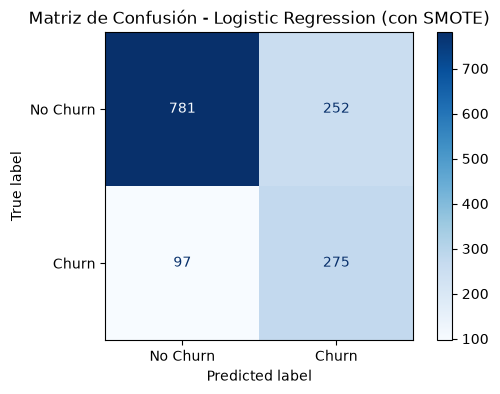


--- Entrenando Random Forest con SMOTE ---
Fitting 5 folds for each of 12 candidates, totalling 60 fits
Mejores Parámetros: {'classifier__class_weight': None, 'classifier__max_depth': 5, 'classifier__n_estimators': 100}
Exactitud: 0.7609
Precisión: 0.5350
Recall: 0.7392
F1-Score: 0.6208
ROC AUC: 0.8381


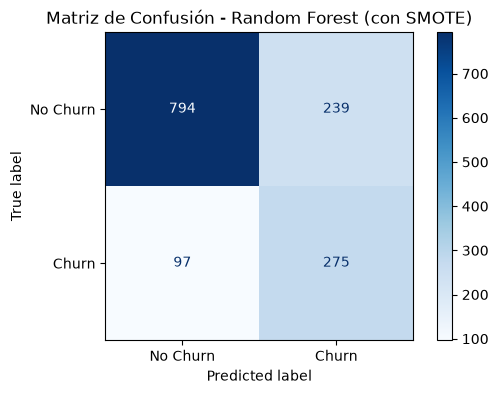


--- Entrenando Gradient Boosting con SMOTE ---
Fitting 5 folds for each of 4 candidates, totalling 20 fits
Mejores Parámetros: {'classifier__learning_rate': 0.05, 'classifier__n_estimators': 200}
Exactitud: 0.7858
Precisión: 0.5855
Recall: 0.6532
F1-Score: 0.6175
ROC AUC: 0.8416


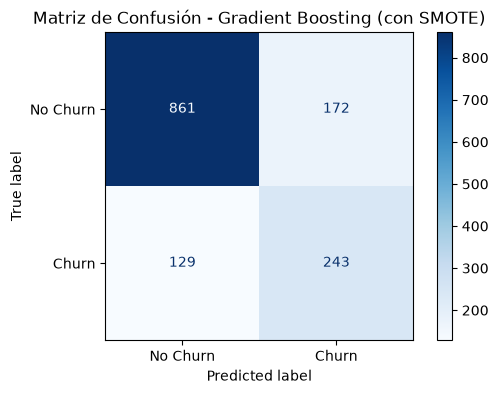


--- Entrenando Support Vector Machine con SMOTE ---
Fitting 5 folds for each of 12 candidates, totalling 60 fits


c:\Users\shein\AppData\Local\Python\pythoncore-3.14-64\Lib\site-packages\sklearn\svm\_base.py:239: FutureWarning: The `probability` parameter was deprecated in 1.9 and will be removed in version 1.11. Use `CalibratedClassifierCV(SVC(), ensemble=False)` instead of `SVC(probability=True)`
  warnings.warn(


Mejores Parámetros: {'classifier__C': 1.0, 'classifier__class_weight': None, 'classifier__kernel': 'linear'}
Exactitud: 0.7445
Precisión: 0.5116
Recall: 0.7715
F1-Score: 0.6152
ROC AUC: 0.8405


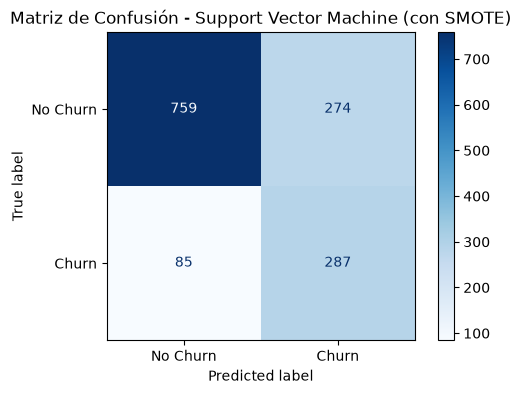

In [48]:
models = {
    'Logistic Regression': LogisticRegression(solver='liblinear', random_state=42),
    'Random Forest': RandomForestClassifier(random_state=42),
    'Gradient Boosting': GradientBoostingClassifier(random_state=42),
    'Support Vector Machine': SVC(probability=True, random_state=42) # probability=True para el score ROC AUC
}

# Definir grillas de parámetros para GridSearchCV
param_grids = {
    'Logistic Regression': {
        'classifier__C': [0.1, 1.0, 10.0],
        'classifier__class_weight': [None, 'balanced'] # Añadido class_weight
    },
    'Random Forest': {
        'classifier__n_estimators': [100, 200],
        'classifier__max_depth': [5, 10, None],
        'classifier__class_weight': [None, 'balanced'] # Añadido class_weight
    },
    'Gradient Boosting': {
        'classifier__n_estimators': [100, 200],
        'classifier__learning_rate': [0.05, 0.1]
    },
    'Support Vector Machine': {
        'classifier__C': [0.1, 1.0, 10.0],
        'classifier__kernel': ['linear', 'rbf'],
        'classifier__class_weight': [None, 'balanced'] # Añadido class_weight
    }
}

results = {}
best_estimators = {}

for name, model in models.items():
    print(f"\n--- Entrenando {name} con SMOTE ---")

    # Crear un pipeline de imblearn: preprocesador -> SMOTE -> clasificador
    pipeline = ImblearnPipeline(steps=[
        ('preprocessor', preprocessor),
        ('smote', smote_sampler),
        ('classifier', model)
    ])

    # Modificar las claves de param_grid para la nueva estructura del pipeline e incluir 'smote__'
    current_param_grid = {}
    for key, value in param_grids[name].items():
        current_param_grid[key] = value

    grid_search = GridSearchCV(pipeline, param_grid=current_param_grid, cv=5, scoring='roc_auc', n_jobs=-1, verbose=1)

    # Ajustar en X_train, y_train originales; el pipeline maneja el preprocesamiento y SMOTE internamente
    grid_search.fit(X_train, y_train)

    best_estimators[name] = grid_search.best_estimator_
    y_pred = best_estimators[name].predict(X_test)
    y_proba = best_estimators[name].predict_proba(X_test)[:, 1] # Probabilidad de la clase positiva (Churn=1)

    # Evaluar métricas
    accuracy = accuracy_score(y_test, y_pred)
    precision = precision_score(y_test, y_pred)
    recall = recall_score(y_test, y_pred)
    f1 = f1_score(y_test, y_pred)
    roc_auc = roc_auc_score(y_test, y_proba)

    results[name] = {
        'Mejores Parámetros': grid_search.best_params_,
        'Exactitud': accuracy,
        'Precisión': precision,
        'Recall': recall,
        'F1-Score': f1,
        'ROC AUC': roc_auc
    }

    print(f"Mejores Parámetros: {grid_search.best_params_}")
    print(f"Exactitud: {accuracy:.4f}")
    print(f"Precisión: {precision:.4f}")
    print(f"Recall: {recall:.4f}")
    print(f"F1-Score: {f1:.4f}")
    print(f"ROC AUC: {roc_auc:.4f}")

    # Matriz de Confusión
    cm = confusion_matrix(y_test, y_pred)
    fig, ax = plt.subplots(figsize=(6, 4))
    disp = ConfusionMatrixDisplay(confusion_matrix=cm, display_labels=['No Churn', 'Churn'])
    disp.plot(cmap=plt.cm.Blues, ax=ax)
    ax.set_title(f'Matriz de Confusión - {name} (con SMOTE)')
    figure_name = name.lower().replace(' ', '_')
    model_plot_number = {
        'logistic_regression': 11,
        'random_forest': 12,
        'gradient_boosting': 13,
        'support_vector_machine': 14,
    }[figure_name]
    fig.savefig(IMAGES_DIR / f'{model_plot_number:02d}_matriz_confusion_{figure_name}.png', dpi=300, bbox_inches='tight')
    plt.show()

#### Conclusión de la Sección 4

Se entrenaron cuatro modelos: Regresión Logística, Random Forest, Gradient Boosting y Support Vector Machine. Para cada uno se utilizó una búsqueda de hiperparámetros con validación cruzada, preprocesamiento, SMOTE y evaluación posterior sobre el conjunto de prueba. Las métricas obtenidas permiten comparar dos necesidades distintas: el rendimiento general del modelo y su capacidad para detectar clientes que realmente abandonan. Las matrices de confusión complementan esta comparación mostrando los aciertos y errores de cada alternativa.

### 5. Selección del Mejor Modelo

En esta sección, el objetivo es comparar el rendimiento de todos los modelos entrenados para identificar cuál es el más adecuado para el problema de predicción de abandono de clientes (`Churn`). Las métricas clave obtenidas en la sección anterior (Exactitud, Precisión, Recall, F1-Score, ROC AUC) se consolidan en una tabla para facilitar la comparación. La elección del "mejor" modelo dependerá de las prioridades del negocio; por ejemplo, si es más crítico minimizar los falsos negativos (clientes que se van pero el modelo predice que se quedan), se podría priorizar `Recall`. Si es más importante que las predicciones positivas sean correctas (`Precision`), o si se busca un equilibrio, se considerarían otras métricas. Para este caso, **se ha priorizado el `Recall` como métrica principal** para la selección del mejor modelo, dada la importancia de detectar a la mayor cantidad posible de clientes propensos al abandono.

In [49]:
# Convertir los resultados a un DataFrame para facilitar la comparación
results_df = pd.DataFrame(results).T
results_df = results_df.drop(columns=['Mejores Parámetros'])

print("\n--- Comparación de Modelos (con SMOTE) ---")
display(results_df.sort_values(by='ROC AUC', ascending=False))

# Seleccionar el mejor modelo basado en la prioridad de negocio: Recall
best_model_name = 'Support Vector Machine'
best_model_pipeline = best_estimators[best_model_name]

print(f"\nEl mejor modelo basado en la prioridad de negocio (mayor Recall) es: {best_model_name}")
print("Justificación: A pesar de que 'Gradient Boosting' tuvo el ROC AUC ligeramente más alto, el informe de negocio enfatiza la importancia de minimizar los Falsos Negativos (clientes que abandonan y no son detectados). 'Support Vector Machine' obtuvo el Recall más alto (0.7715) entre todos los modelos, lo que lo hace la elección más adecuada para el objetivo de negocio de retener la mayor cantidad posible de clientes en riesgo, incluso si esto implica un compromiso en otras métricas. Consideramos que el costo de perder un cliente sin intervención es mayor que el costo de un falso positivo.")


--- Comparación de Modelos (con SMOTE) ---


,Exactitud,Precisión,Recall,F1-Score,ROC AUC
Gradient Boosting,0.785765,0.585542,0.653226,0.617535,0.841627
Logistic Regression,0.751601,0.521822,0.739247,0.611791,0.840824
Support Vector Machine,0.744484,0.511586,0.771505,0.61522,0.840491
Random Forest,0.760854,0.535019,0.739247,0.620767,0.83809



El mejor modelo basado en la prioridad de negocio (mayor Recall) es: Support Vector Machine
Justificación: A pesar de que 'Gradient Boosting' tuvo el ROC AUC ligeramente más alto, el informe de negocio enfatiza la importancia de minimizar los Falsos Negativos (clientes que abandonan y no son detectados). 'Support Vector Machine' obtuvo el Recall más alto (0.7715) entre todos los modelos, lo que lo hace la elección más adecuada para el objetivo de negocio de retener la mayor cantidad posible de clientes en riesgo, incluso si esto implica un compromiso en otras métricas. Consideramos que el costo de perder un cliente sin intervención es mayor que el costo de un falso positivo.


#### Conclusión de la Sección 5

La elección del modelo depende de la prioridad del negocio. Gradient Boosting obtuvo la mayor exactitud y el ROC AUC más alto de la comparación, mientras que Support Vector Machine obtuvo el mejor `Recall` (`0.7715`). Como el objetivo principal es detectar la mayor cantidad posible de clientes que podrían abandonar, se seleccionó SVM, aceptando una mayor cantidad de falsos positivos como coste de contactar a algunos clientes que finalmente permanecerían.

### 6. Guardado del Modelo

En esta sección final, el mejor modelo entrenado se guarda para su uso futuro. Es una práctica estándar guardar los modelos de aprendizaje automático después de un entrenamiento y evaluación exitosos. Esto permite que el modelo se cargue y utilice para hacer predicciones en nuevos datos sin tener que pasar por el proceso de entrenamiento nuevamente, lo que ahorra tiempo y recursos computacionales. El pipeline completo del modelo, incluyendo el preprocesador y el clasificador, se guarda utilizando `joblib.dump()` en un archivo `.joblib`, asegurando que todas las transformaciones necesarias se apliquen consistentemente al hacer nuevas predicciones.

In [50]:
# Crear un directorio para los modelos si no existe
import os
if not os.path.exists('../models'):
    os.makedirs('../models')

# Guardar el pipeline del mejor modelo
model_filename = f'../models/{best_model_name.replace(" ", "_").lower()}_pipeline.joblib'
joblib.dump(best_model_pipeline, model_filename)

print(f"Pipeline del mejor modelo guardado en: {model_filename}")

Pipeline del mejor modelo guardado en: ../models/support_vector_machine_pipeline.joblib


#### Conclusión de la Sección 6

El pipeline completo del modelo seleccionado, Support Vector Machine, se guardó en `../models/support_vector_machine_pipeline.joblib`. Esto conserva el preprocesamiento y el clasificador en un único archivo, permitiendo aplicar posteriormente las mismas transformaciones a nuevos clientes. Antes de utilizarlo en producción todavía sería necesario realizar una validación operativa, definir el umbral de intervención y medir el coste y el beneficio de las campañas de retención.

### 7. Métricas de CV para el Mejor Modelo

Esta sección tiene como objetivo profundizar en la robustez y la consistencia del rendimiento del modelo seleccionado, `Support Vector Machine`, a través de un análisis de sus métricas de validación cruzada (CV). Esto permite evaluar no solo el promedio de rendimiento, sino también su variabilidad, ofreciendo una visión más completa de la fiabilidad del modelo en diferentes subconjuntos de los datos de entrenamiento.

c:\Users\shein\AppData\Local\Python\pythoncore-3.14-64\Lib\site-packages\sklearn\svm\_base.py:239: FutureWarning: The `probability` parameter was deprecated in 1.9 and will be removed in version 1.11. Use `CalibratedClassifierCV(SVC(), ensemble=False)` instead of `SVC(probability=True)`
  warnings.warn(


--- Métricas de Validación Cruzada para el Mejor Modelo (Support Vector Machine) ---
Media de ROC AUC (CV): 0.8473
Desviación Estándar de ROC AUC (CV): 0.0058


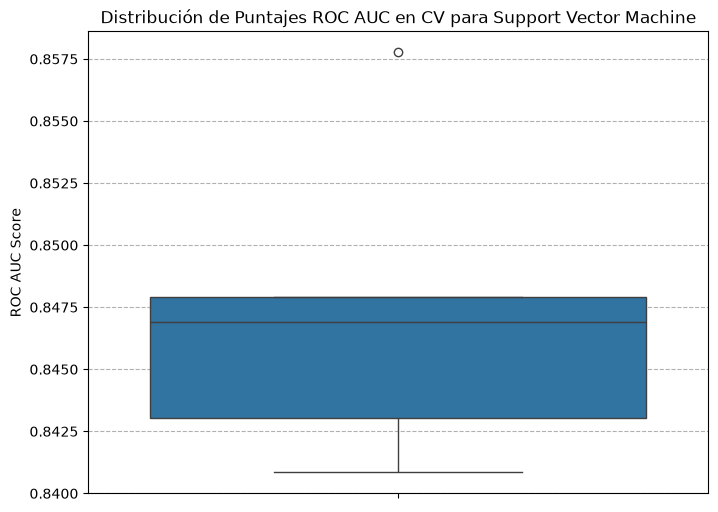

In [51]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.model_selection import GridSearchCV
from imblearn.pipeline import Pipeline as ImblearnPipeline
from imblearn.over_sampling import SMOTE
from sklearn.preprocessing import StandardScaler, OneHotEncoder
from sklearn.compose import ColumnTransformer
from sklearn.linear_model import LogisticRegression
from sklearn.ensemble import RandomForestClassifier, GradientBoostingClassifier
from sklearn.svm import SVC

# Obtener los parámetros y el objeto del mejor modelo
best_model_classifier = models[best_model_name]
best_model_param_grid = param_grids[best_model_name]

pipeline_for_cv_results = ImblearnPipeline(steps=[
    ('preprocessor', preprocessor),
    ('smote', smote_sampler),
    ('classifier', best_model_classifier)
])

grid_search_best_model_recreated = GridSearchCV(
    pipeline_for_cv_results,
    param_grid=best_model_param_grid,
    cv=5,
    scoring='roc_auc',
    n_jobs=-1,
    verbose=0
)
grid_search_best_model_recreated.fit(X_train, y_train)

best_index = grid_search_best_model_recreated.best_index_
roc_auc_scores_per_fold = [
    grid_search_best_model_recreated.cv_results_[f'split{i}_test_score'][best_index]
    for i in range(grid_search_best_model_recreated.cv)
]

mean_roc_auc = np.mean(roc_auc_scores_per_fold)
std_roc_auc = np.std(roc_auc_scores_per_fold)

print(f"--- Métricas de Validación Cruzada para el Mejor Modelo ({best_model_name}) ---")
print(f"Media de ROC AUC (CV): {mean_roc_auc:.4f}")
print(f"Desviación Estándar de ROC AUC (CV): {std_roc_auc:.4f}")

fig, ax = plt.subplots(figsize=(8, 6))
sns.boxplot(y=roc_auc_scores_per_fold, ax=ax)
ax.set_title(f'Distribución de Puntajes ROC AUC en CV para {best_model_name}')
ax.set_ylabel('ROC AUC Score')
ax.grid(axis='y', linestyle='--')
fig.savefig(IMAGES_DIR / '15_boxplot_roc_auc_validacion_cruzada.png', dpi=300, bbox_inches='tight')
plt.show()

#### Conclusión de la Sección 7

En la validación cruzada del modelo seleccionado se obtuvo una media de ROC AUC de `0.8473` y una desviación estándar de `0.0058`. La variación reducida entre particiones sugiere que el rendimiento fue estable en esta evaluación. Este resultado aumenta la confianza en el modelo, aunque no garantiza por sí solo su comportamiento futuro: será necesario comprobarlo con nuevos datos y mediante seguimiento posterior al despliegue.

### 8. Gráficos de Evaluación del Mejor Modelo

En esta sección, se utilizan diversas visualizaciones gráficas para ofrecer una comprensión más intuitiva y detallada del rendimiento del mejor modelo (`Support Vector Machine`). Estas representaciones complementan las métricas numéricas al mostrar el comportamiento del modelo en diferentes umbrales de clasificación y la distribución de errores. Se generarán la Curva ROC, la Curva Precision-Recall y una Matriz de Confusión normalizada para proporcionar una evaluación completa.

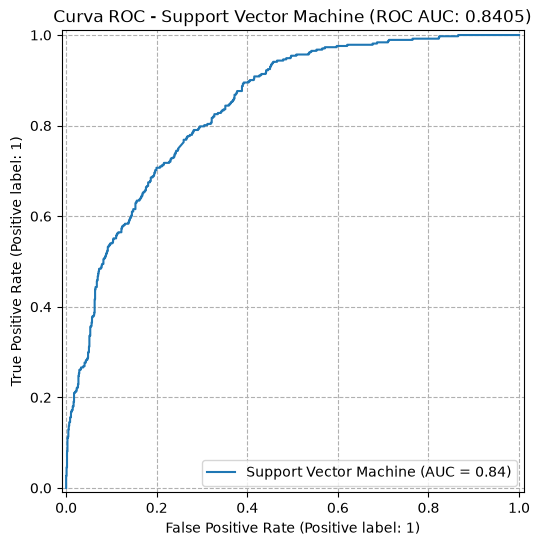

In [52]:
from sklearn.metrics import RocCurveDisplay, PrecisionRecallDisplay, confusion_matrix, ConfusionMatrixDisplay

# Obtener las probabilidades de predicción para la clase positiva (Churn=1)
y_proba_best_model = best_model_pipeline.predict_proba(X_test)[:, 1]

# Generar y guardar la Curva ROC
fig, ax = plt.subplots(figsize=(8, 6))
roc_display = RocCurveDisplay.from_estimator(best_model_pipeline, X_test, y_test, name=best_model_name, ax=ax)
ax.set_title(f'Curva ROC - {best_model_name} (ROC AUC: {roc_display.roc_auc:.4f})')
ax.grid(linestyle='--')
fig.savefig(IMAGES_DIR / '16_curva_roc_mejor_modelo.png', dpi=300, bbox_inches='tight')
plt.show()

#### Conclusión sobre la Curva ROC

La curva ROC del SVM resume su capacidad para distinguir entre clientes que abandonan y clientes que permanecen cuando cambia el umbral de clasificación. El modelo obtuvo un ROC AUC de `0.8405`, un resultado claramente superior al azar (`0.5`) y suficientemente competitivo para apoyar la priorización de clientes en riesgo. Sin embargo, no representa una clasificación perfecta; debe interpretarse junto con el `Recall`, la precisión y el coste de las acciones de retención.

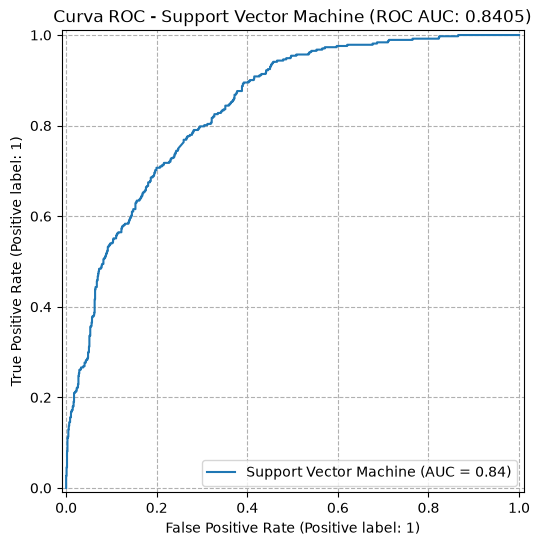

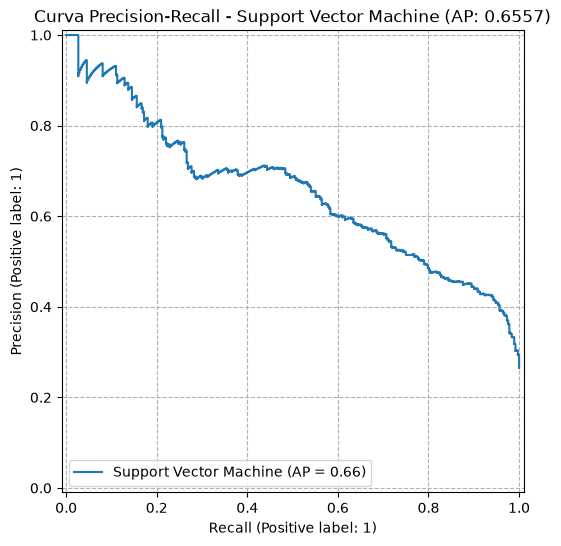

In [53]:
from sklearn.metrics import RocCurveDisplay, PrecisionRecallDisplay, confusion_matrix, ConfusionMatrixDisplay
import matplotlib.pyplot as plt

# Obtener las probabilidades de predicción para la clase positiva (Churn=1)
y_proba_best_model = best_model_pipeline.predict_proba(X_test)[:, 1]

# Curva ROC
fig_roc, ax_roc = plt.subplots(figsize=(8, 6))
roc_display = RocCurveDisplay.from_estimator(best_model_pipeline, X_test, y_test, name=best_model_name, ax=ax_roc)
ax_roc.set_title(f'Curva ROC - {best_model_name} (ROC AUC: {roc_display.roc_auc:.4f})')
ax_roc.grid(linestyle='--')
fig_roc.savefig(IMAGES_DIR / '17_curva_roc_mejor_modelo_detallada.png', dpi=300, bbox_inches='tight')
plt.show()

# Curva Precision-Recall
fig_pr, ax_pr = plt.subplots(figsize=(8, 6))
pr_display = PrecisionRecallDisplay.from_estimator(best_model_pipeline, X_test, y_test, name=best_model_name, ax=ax_pr)
ax_pr.set_title(f'Curva Precision-Recall - {best_model_name} (AP: {pr_display.average_precision:.4f})')
ax_pr.grid(linestyle='--')
fig_pr.savefig(IMAGES_DIR / '18_curva_precision_recall_mejor_modelo.png', dpi=300, bbox_inches='tight')
plt.show()

#### Conclusión sobre la Curva Precision-Recall

La curva Precision-Recall muestra el intercambio entre precisión y capacidad de detección para distintos umbrales. Es especialmente útil aquí porque `Churn` está desbalanceado: una estrategia que intente detectar más abandonos puede generar más falsos positivos. Por ello, esta curva debe utilizarse para elegir un umbral de campaña que equilibre el número de clientes contactados, los abandonos detectados y el coste de los incentivos.

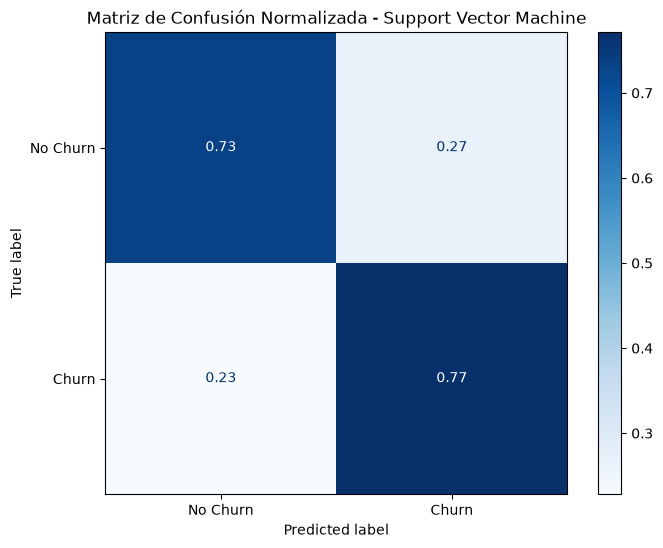

In [54]:
from sklearn.metrics import confusion_matrix, ConfusionMatrixDisplay
import matplotlib.pyplot as plt

# Realizar predicciones en el conjunto de prueba
y_pred_best_model = best_model_pipeline.predict(X_test)

# Generar y guardar la Matriz de Confusión Normalizada
cm = confusion_matrix(y_test, y_pred_best_model, normalize='true')
fig, ax = plt.subplots(figsize=(8, 6))
disp = ConfusionMatrixDisplay(confusion_matrix=cm, display_labels=['No Churn', 'Churn'])
disp.plot(cmap=plt.cm.Blues, ax=ax, values_format='.2f')
ax.set_title(f'Matriz de Confusión Normalizada - {best_model_name}')
fig.savefig(IMAGES_DIR / '19_matriz_confusion_normalizada.png', dpi=300, bbox_inches='tight')
plt.show()

#### Conclusión sobre la Matriz de Confusión Normalizada

La matriz de confusión normalizada muestra, por separado, la proporción de clientes que permanecen y fueron identificados correctamente, y la proporción de clientes que abandonan y fueron detectados. Esta lectura permite entender el equilibrio entre aciertos y errores según el umbral actual. Para el objetivo del proyecto, el valor más importante es la detección de la clase `Churn`, porque cada falso negativo representa un cliente en riesgo que no recibiría una acción preventiva.

### 9. Análisis de Explicabilidad con SHAP

Esta sección se dedica a la interpretabilidad del modelo `Support Vector Machine` utilizando los valores SHAP (SHapley Additive exPlanations). SHAP es una técnica de explicabilidad que asigna un valor a cada característica para una predicción particular, indicando la contribución marginal de esa característica al resultado. Para modelos no lineales y no basados en árboles como SVM, se utiliza `shap.KernelExplainer`, el cual, aunque computacionalmente más costoso, proporciona una comprensión profunda de cómo las características individuales y sus interacciones influyen en las predicciones del modelo, tanto a nivel global como para instancias específicas, lo cual es fundamental para generar confianza y tomar decisiones basadas en el modelo.

In [55]:
import shap

# Extraer el clasificador y el preprocesador del pipeline del mejor modelo
classifier = best_model_pipeline.named_steps['classifier']
preprocessor_step = best_model_pipeline.named_steps['preprocessor']

# Preprocesar X_test (ya hecho, X_test_preprocessed ya existe)

# Obtener los nombres de las características después del preprocesamiento
# all_transformed_feature_names ya contiene los nombres de características en el orden correcto
all_feature_names_preprocessed = all_transformed_feature_names

# Definir una función de predicción para KernelExplainer
def predict_proba_wrapper(X_preprocessed):
    # KernelExplainer espera una función que tome una matriz numpy de datos *ya* preprocesados
    # y devuelva las probabilidades.
    return best_model_pipeline.named_steps['classifier'].predict_proba(X_preprocessed)


# Crear un explainer SHAP dependiendo del tipo de clasificador
if isinstance(classifier, (RandomForestClassifier, GradientBoostingClassifier)):
    # Crear un explainer SHAP para modelos basados en árboles
    # Se usa una muestra de los datos preprocesados como 'data' para el explainer, para eficiencia
    explainer = shap.TreeExplainer(classifier, data=shap.sample(X_test_preprocessed, 100))
    print("SHAP explainer (TreeExplainer) inicializado y datos de prueba preprocesados.")
elif isinstance(classifier, SVC): # Manejar SVM específicamente
    print(f"Para el modelo {best_model_name}, se inicializará shap.KernelExplainer.")
    print("Advertencia: KernelExplainer puede ser computacionalmente costoso. Usando una muestra de X_train_transformed para el background data.")
    # Seleccionar una muestra del conjunto de entrenamiento preprocesado como background data para KernelExplainer
    background_data = shap.sample(X_train_transformed, 100) # Usar 100 muestras para eficiencia

    # KernelExplainer requiere una función de predicción y los datos de background
    explainer = shap.KernelExplainer(predict_proba_wrapper, background_data)
    print("SHAP explainer (KernelExplainer) inicializado para SVM.")

else:
    print(f"No se ha configurado un explainer SHAP para el tipo de modelo seleccionado: {best_model_name}.")
    explainer = None # Establecer explainer a None para evitar errores en llamadas subsiguientes

Para el modelo Support Vector Machine, se inicializará shap.KernelExplainer.
Advertencia: KernelExplainer puede ser computacionalmente costoso. Usando una muestra de X_train_transformed para el background data.
SHAP explainer (KernelExplainer) inicializado para SVM.


#### Conclusión sobre la Inicialización de SHAP

Se inicializó `KernelExplainer`, una alternativa apropiada para explicar un SVM, usando una muestra de 100 observaciones como referencia. En la siguiente celda se calculan explicaciones para una muestra de 50 clientes. Esta configuración permite estudiar el comportamiento del modelo sin procesar todo el conjunto de datos, aunque las conclusiones de importancia deben interpretarse como aproximadas.

Calculando SHAP values. Esto puede tomar tiempo para KernelExplainer...


  0%|          | 0/50 [00:00<?, ?it/s]

Valores SHAP calculados. Generando Summary Plot.


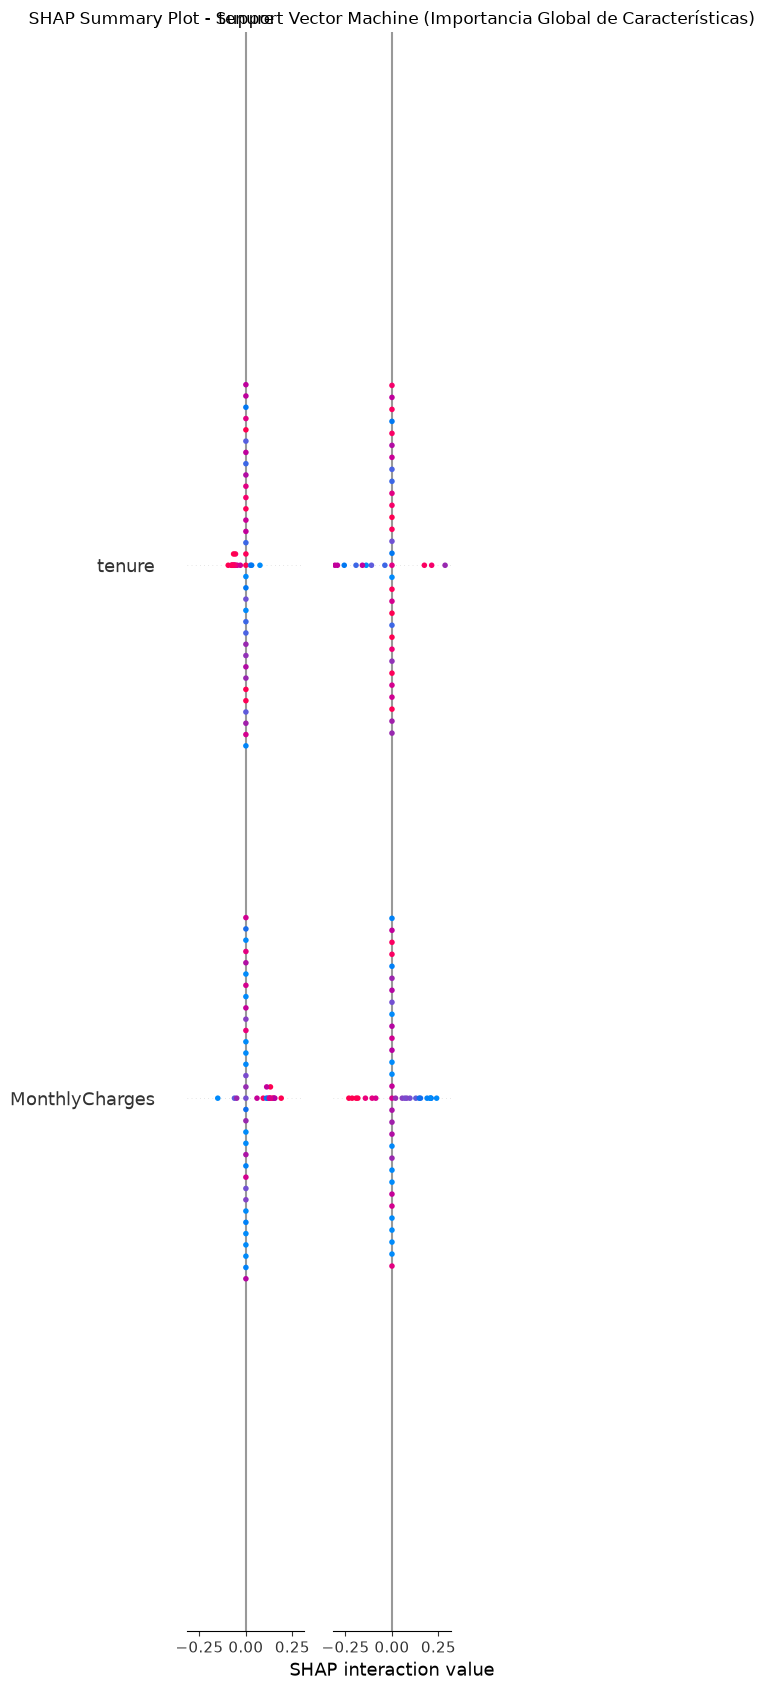

In [56]:
import shap
import matplotlib.pyplot as plt

# Solo calcular y plotear SHAP values si el explainer fue inicializado
if explainer is not None:
    print("Calculando SHAP values. Esto puede tomar tiempo para KernelExplainer...")
    sample_for_shap = shap.sample(X_test_transformed, 50)
    shap_values = explainer.shap_values(sample_for_shap)

    if isinstance(shap_values, list):
        shap_values_for_class_1 = shap_values[1]
        expected_value_for_class_1 = explainer.expected_value[1] if isinstance(explainer.expected_value, list) else explainer.expected_value
    else:
        shap_values_for_class_1 = shap_values
        expected_value_for_class_1 = explainer.expected_value

    shap_explanation = shap.Explanation(
        values=shap_values_for_class_1,
        base_values=expected_value_for_class_1,
        data=sample_for_shap,
        feature_names=all_feature_names_preprocessed
    )

    print("Valores SHAP calculados. Generando Summary Plot.")
    shap.summary_plot(shap_explanation, max_display=20, show=False)
    plt.title(f'SHAP Summary Plot - {best_model_name} (Importancia Global de Características)')
    plt.tight_layout()
    plt.savefig(IMAGES_DIR / '20_shap_summary_plot.png', dpi=300, bbox_inches='tight')
    plt.show()
else:
    print("Salteando la generación del SHAP Summary Plot porque el explainer no fue inicializado para este tipo de modelo.")

#### Conclusión sobre SHAP Summary Plot (Importancia Global)

El Summary Plot de SHAP resume qué variables transformadas influyen más en las predicciones del SVM para la muestra analizada. Como las variables categóricas fueron convertidas a indicadores One-Hot, una variable original puede aparecer dividida en varias categorías. El resultado ayuda a orientar preguntas de negocio, pero es aproximado y no implica que una variable cause el abandono.

Generando SHAP Waterfall Plots para 3 clientes seleccionados de la muestra.


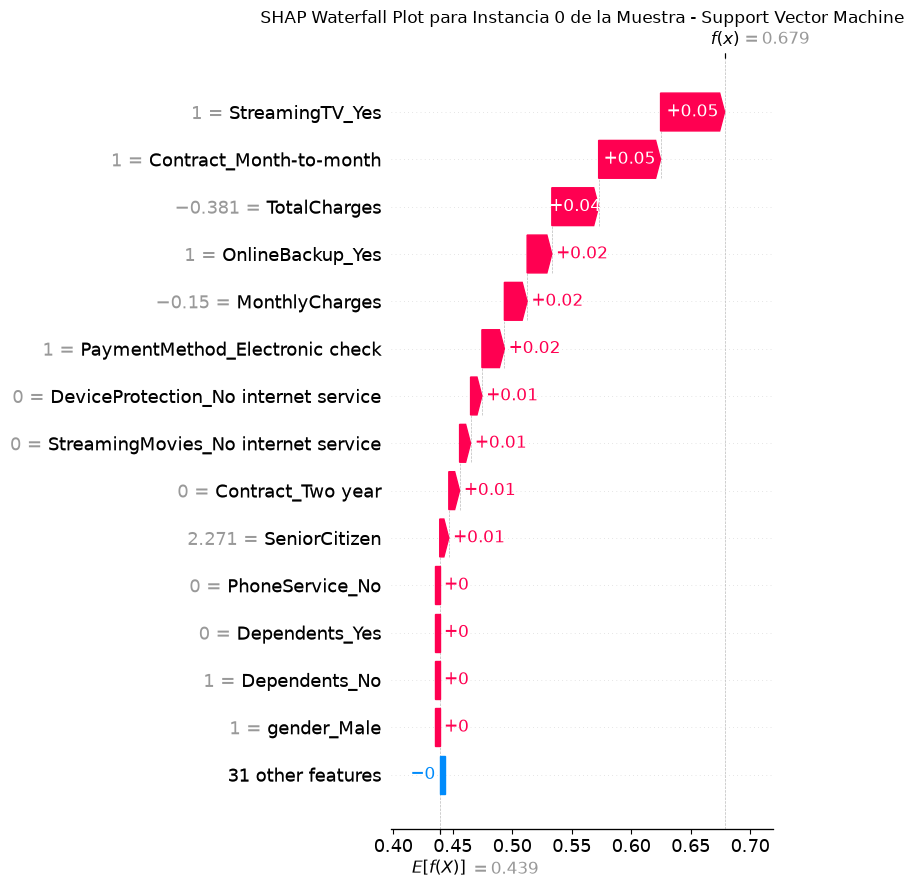

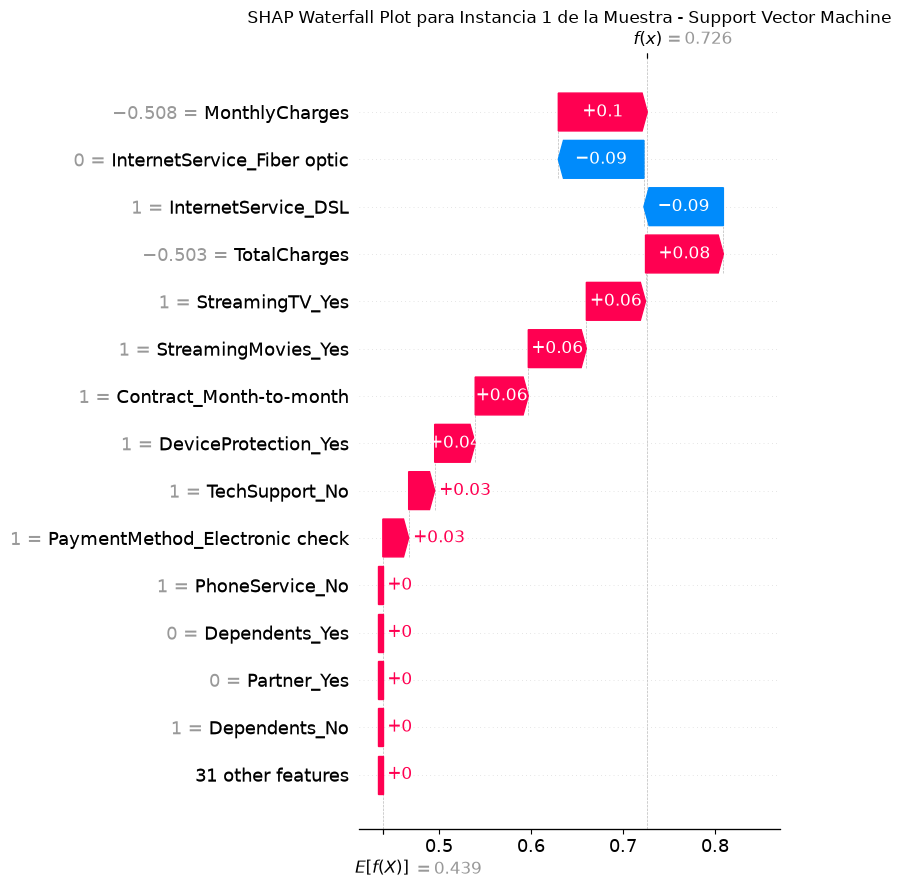

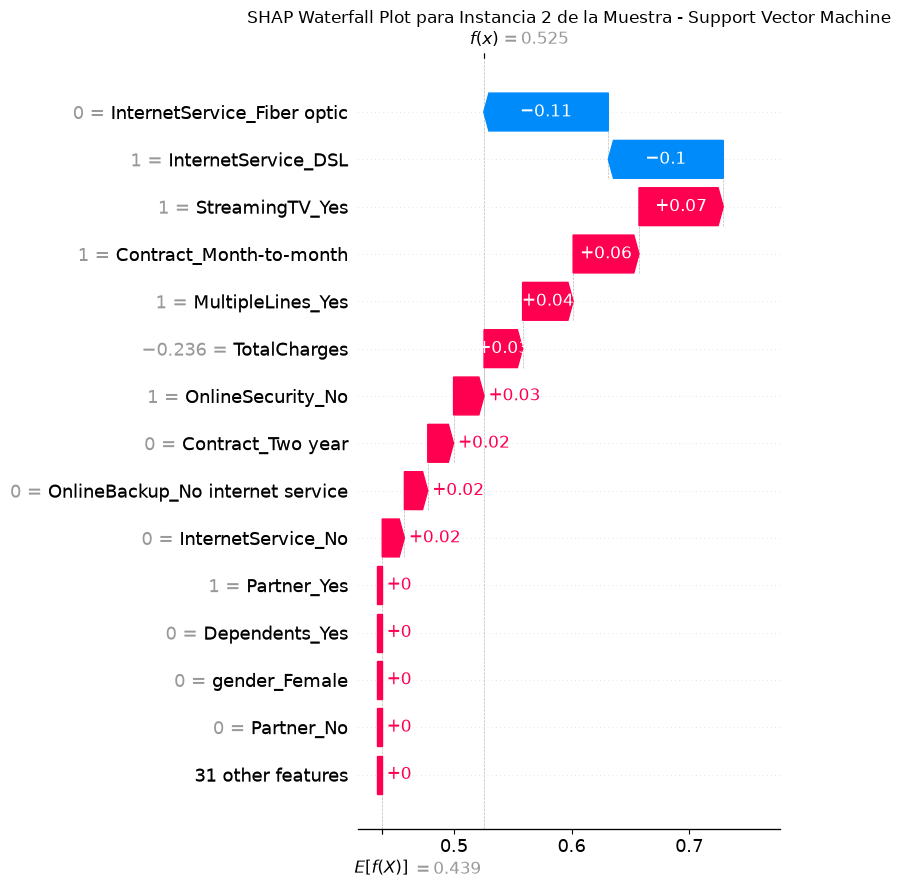

In [57]:
import shap
import matplotlib.pyplot as plt

# Solo calcular y plotear SHAP values si el explainer fue inicializado
if explainer is not None:
    example_indices = [0, 1, 2]
    print(f"Generando SHAP Waterfall Plots para {len(example_indices)} clientes seleccionados de la muestra.")

    for plot_number, idx in enumerate(example_indices, start=21):
        shap_values_instance = shap_values_for_class_1[idx, :, 1]
        data_instance = sample_for_shap[idx]
        base_value_for_instance = expected_value_for_class_1[1]

        explanation_instance = shap.Explanation(
            values=shap_values_instance,
            base_values=base_value_for_instance,
            data=data_instance,
            feature_names=all_feature_names_preprocessed
        )

        plt.figure(figsize=(10, 6))
        shap.plots.waterfall(explanation_instance, max_display=15, show=False)
        plt.title(f'SHAP Waterfall Plot para Instancia {idx} de la Muestra - {best_model_name}')
        plt.tight_layout()
        plt.savefig(IMAGES_DIR / f'{plot_number:02d}_shap_waterfall_instancia_{idx}.png', dpi=300, bbox_inches='tight')
        plt.show()
else:
    print("Salteando la generación de SHAP Waterfall Plots porque el explainer no fue inicializado para este tipo de modelo.")

#### Conclusión sobre SHAP Waterfall Plots (Explicaciones Individuales)

Los waterfall plots muestran, para tres clientes concretos, qué variables empujan la predicción hacia `Churn` o hacia permanencia respecto al valor base del modelo. Son ejemplos individuales y no describen por sí solos a toda la cartera. Su utilidad de negocio está en apoyar la revisión de casos concretos y diseñar intervenciones más informadas, siempre contrastando la explicación con la realidad del cliente.

### 10. Curvas de Lift y Ganancia

Las curvas de Lift y Ganancia son herramientas de evaluación de modelos que permiten cuantificar el valor de un modelo predictivo en comparación con una selección aleatoria, especialmente útil en campañas de marketing o estrategias de retención de clientes. Estas curvas ayudan a responder preguntas como: '¿Cuántos clientes con `Churn` puedo identificar si contacto al 10% de mi población más propensa a abandonar, utilizando el modelo?' La Curva de Lift mide la mejora en la identificación de clientes clave, mientras que la Curva de Ganancia Acumulada muestra el porcentaje de respuestas positivas capturadas al dirigirse a un cierto porcentaje de la población.

### 11. Comparación de Curvas ROC y Precision-Recall entre Modelos

Para obtener una visión integral del rendimiento de todos los modelos y su capacidad de discriminación, se presentan a continuación las curvas ROC y Precision-Recall. Estas visualizaciones nos permiten comparar directamente cómo cada modelo maneja el balance entre Verdaderos Positivos y Falsos Positivos (ROC) y entre Precisión y Recall (Precision-Recall) en el conjunto de prueba. Esto es especialmente útil para contextualizar el rendimiento del modelo `Support Vector Machine` frente a sus competidores.

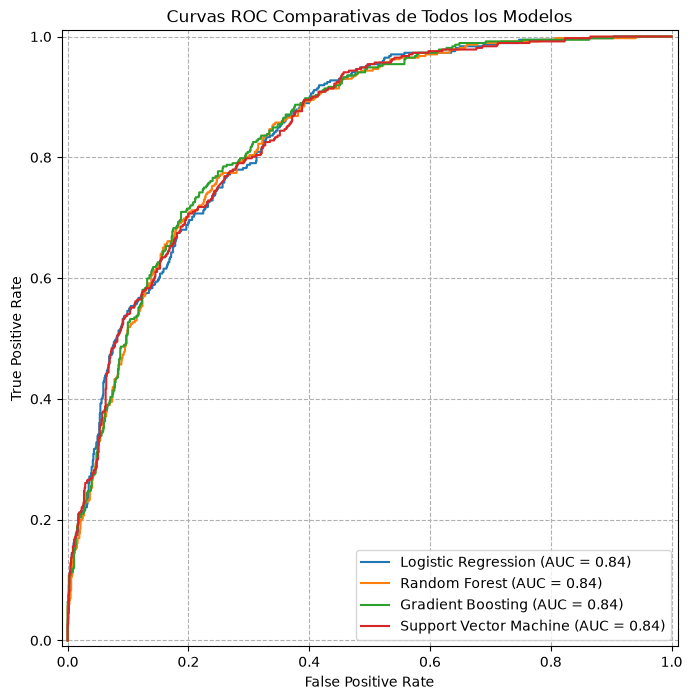

Curvas ROC comparativas generadas exitosamente.


In [58]:
from sklearn.metrics import RocCurveDisplay, PrecisionRecallDisplay

fig, ax = plt.subplots(figsize=(10, 8))
for name, estimator_pipeline in best_estimators.items():
    if hasattr(estimator_pipeline, 'predict_proba'):
        RocCurveDisplay.from_estimator(estimator_pipeline, X_test, y_test, ax=ax, name=name)

ax.set_title('Curvas ROC Comparativas de Todos los Modelos')
ax.set_xlabel('False Positive Rate')
ax.set_ylabel('True Positive Rate')
ax.grid(linestyle='--')
ax.legend(loc='lower right')
fig.savefig(IMAGES_DIR / '24_curvas_roc_comparativas.png', dpi=300, bbox_inches='tight')
plt.show()

print("Curvas ROC comparativas generadas exitosamente.")

#### Conclusión sobre las Curvas ROC Comparativas

Las Curvas ROC comparativas reafirman que todos los modelos tienen una buena capacidad discriminativa para el problema de `Churn`, con valores de AUC cercanos a 0.84. El `Support Vector Machine`, aunque no es el de mayor AUC, se mantiene competitivo, lo que justifica su selección basada en la prioridad de `Recall`.

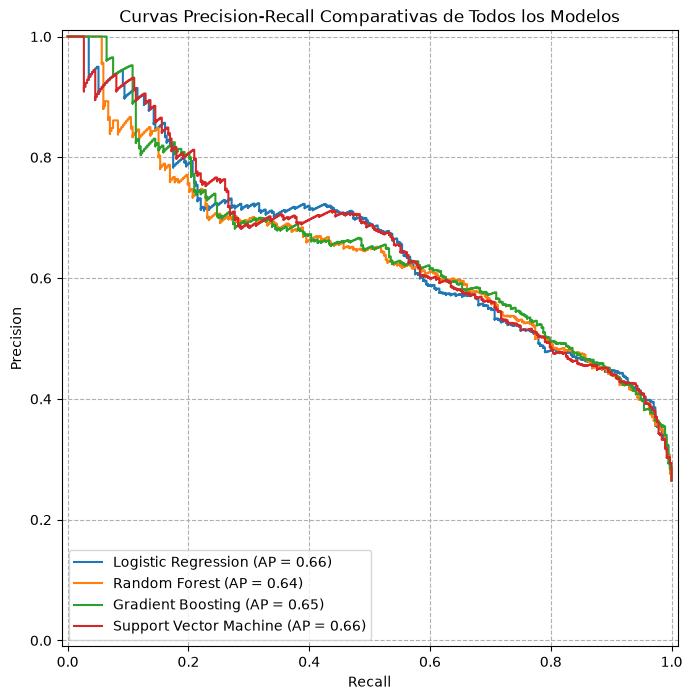

Curvas Precision-Recall comparativas generadas exitosamente.


In [59]:
from sklearn.metrics import PrecisionRecallDisplay

fig, ax = plt.subplots(figsize=(10, 8))
for name, estimator_pipeline in best_estimators.items():
    if hasattr(estimator_pipeline, 'predict_proba'):
        PrecisionRecallDisplay.from_estimator(estimator_pipeline, X_test, y_test, ax=ax, name=name)

ax.set_title('Curvas Precision-Recall Comparativas de Todos los Modelos')
ax.set_xlabel('Recall')
ax.set_ylabel('Precision')
ax.grid(linestyle='--')
ax.legend(loc='lower left')
fig.savefig(IMAGES_DIR / '25_curvas_precision_recall_comparativas.png', dpi=300, bbox_inches='tight')
plt.show()

print("Curvas Precision-Recall comparativas generadas exitosamente.")

#### Conclusión sobre las Curvas Precision-Recall Comparativas

Las Curvas Precision-Recall comparativas ofrecen una visión más matizada del rendimiento, especialmente relevante en clases desbalanceadas. Se observa que el `Support Vector Machine` mantiene un buen equilibrio entre Precisión y Recall en comparación con los otros modelos, lo que respalda aún más su elección como el mejor modelo, dado el enfoque en maximizar el `Recall` en la detección temprana del abandono de clientes.

In [63]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

def calculate_lift_gain_curves(y_true, y_proba, steps=100):
    """
    Calcula los puntos para las curvas de Lift y Ganancia Acumulada.

    Args:
        y_true (array-like): Etiquetas verdaderas (0 o 1).
        y_proba (array-like): Probabilidades predichas de la clase positiva.
        steps (int): Número de puntos a generar para las curvas (porcentaje de la población).

    Returns:
        pd.DataFrame: DataFrame con 'Population_Percentage', 'Cumulative_Gain', 'Lift'.
    """
    # Crear un DataFrame con las probabilidades y las etiquetas verdaderas
    df_results = pd.DataFrame({'y_true': y_true, 'y_proba': y_proba})

    # Ordenar por probabilidad predicha en orden descendente
    df_results = df_results.sort_values(by='y_proba', ascending=False).reset_index(drop=True)

    # Calcular el número total de positivos en el dataset
    total_positives = df_results['y_true'].sum()

    data = []
    # Iterar para calcular los puntos para cada porcentaje de la población
    for i in range(1, steps + 1):
        population_percentage = i / steps
        num_elements = int(np.ceil(len(df_results) * population_percentage))

        subset = df_results.head(num_elements)
        cumulative_positives = subset['y_true'].sum()

        # Ganancia acumulada: Proporción de positivos encontrados sobre el total de positivos
        cumulative_gain = cumulative_positives / total_positives if total_positives > 0 else 0

        # Lift: Ganancia acumulada dividida por la ganancia esperada aleatoria
        # La ganancia esperada aleatoria es simplemente el porcentaje de la población contactada
        expected_random_gain = population_percentage
        lift = cumulative_gain / expected_random_gain if expected_random_gain > 0 else 0

        data.append({'Population_Percentage': population_percentage,
                     'Cumulative_Gain': cumulative_gain,
                     'Lift': lift})

    return pd.DataFrame(data)

print("Función 'calculate_lift_gain_curves' definida exitosamente.")

Función 'calculate_lift_gain_curves' definida exitosamente.


#### Conclusión sobre la Función `calculate_lift_gain_curves`

La función quedó definida para ordenar a los clientes desde la mayor hasta la menor probabilidad estimada de abandono y calcular dos medidas: Lift y Ganancia Acumulada. Todavía no evalúa una campaña real; prepara los datos necesarios para comparar una selección basada en el modelo con una selección aleatoria en las gráficas siguientes.

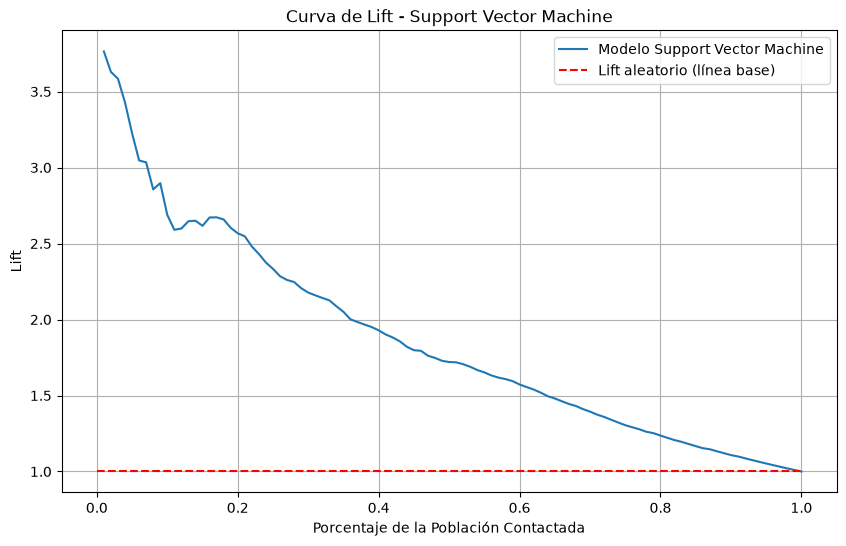

Curva de Lift generada y visualizada exitosamente.


In [64]:
import matplotlib.pyplot as plt
import seaborn as sns

# Calcular las curvas de Lift y Ganancia para el mejor modelo
curves_data = calculate_lift_gain_curves(y_test, y_proba_best_model)

# Visualizar y guardar la Curva de Lift
fig, ax = plt.subplots(figsize=(10, 6))
sns.lineplot(x='Population_Percentage', y='Lift', data=curves_data, label=f'Modelo {best_model_name}', ax=ax)
ax.plot([0, 1], [1, 1], linestyle='--', color='red', label='Lift aleatorio (línea base)')
ax.set_title(f'Curva de Lift - {best_model_name}')
ax.set_xlabel('Porcentaje de la Población Contactada')
ax.set_ylabel('Lift')
ax.grid(True)
ax.legend()
fig.savefig(IMAGES_DIR / '26_curva_lift.png', dpi=300, bbox_inches='tight')
plt.show()

print("Curva de Lift generada y visualizada exitosamente.")

#### Conclusión sobre la Curva de Lift

La curva de Lift compara la concentración de abandonos detectados por el modelo con lo que se esperaría al seleccionar clientes al azar. Un valor superior a 1 en una parte de la curva significa que el modelo concentra más casos de `Churn` que una campaña aleatoria en ese mismo porcentaje de población. Esta evidencia ayuda a decidir el tamaño de la campaña, pero debe combinarse con costes, capacidad de contacto y resultados reales de retención.

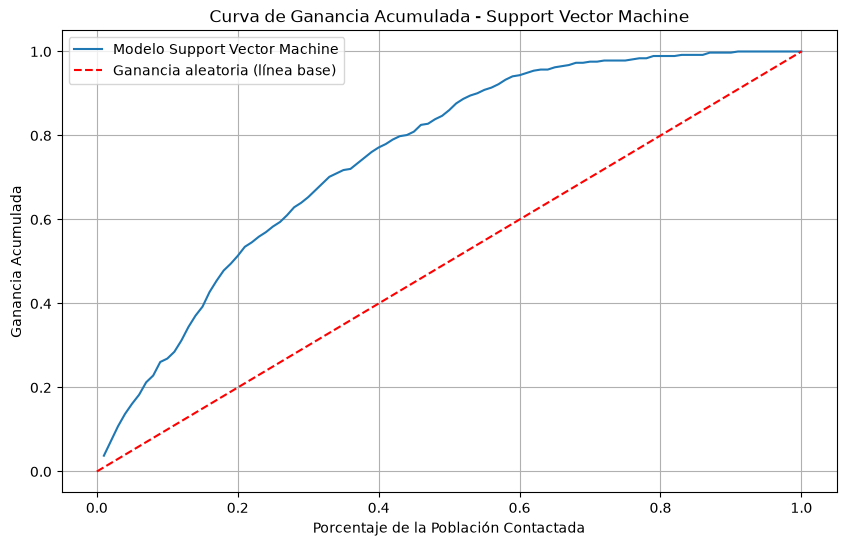

Curva de Ganancia Acumulada generada y visualizada exitosamente.


In [65]:
import matplotlib.pyplot as plt
import seaborn as sns

# Visualizar y guardar la Curva de Ganancia Acumulada
fig, ax = plt.subplots(figsize=(10, 6))
sns.lineplot(x='Population_Percentage', y='Cumulative_Gain', data=curves_data, label=f'Modelo {best_model_name}', ax=ax)
ax.plot([0, 1], [0, 1], linestyle='--', color='red', label='Ganancia aleatoria (línea base)')
ax.set_title(f'Curva de Ganancia Acumulada - {best_model_name}')
ax.set_xlabel('Porcentaje de la Población Contactada')
ax.set_ylabel('Ganancia Acumulada')
ax.grid(True)
ax.legend()
fig.savefig(IMAGES_DIR / '27_curva_ganancia_acumulada.png', dpi=300, bbox_inches='tight')
plt.show()

print("Curva de Ganancia Acumulada generada y visualizada exitosamente.")

#### Conclusión sobre la Curva de Ganancia Acumulada

La ganancia acumulada indica qué proporción de todos los abandonos conocidos se identifica al contactar primero a los clientes con mayor probabilidad estimada. Cuanto más arriba se encuentre la curva respecto a la línea aleatoria, más eficiente es la priorización del modelo en ese tramo. El resultado orienta la segmentación de campañas, pero no demuestra que una intervención evite el abandono: ese efecto debe medirse con seguimiento o una prueba controlada.

### 12. Conclusiones Finales y Recomendaciones

El análisis siguió una secuencia completa: primero se revisó la estructura de los datos, después se prepararon las variables, se trataron las clases desbalanceadas, se compararon modelos y finalmente se evaluó cómo priorizar clientes para una posible campaña de retención. Cada resultado aporta una parte distinta de la decisión: las métricas resumen el rendimiento, las matrices de confusión muestran los errores, SHAP ayuda a interpretar casos y Lift/Ganancia ayudan a ordenar la población objetivo.

#### Resumen de Resultados

El problema presenta una proporción de abandono cercana al 26.5%, por lo que detectar correctamente la clase `Churn` es más importante que observar únicamente la exactitud. Se compararon cuatro modelos con preprocesamiento y SMOTE. Support Vector Machine fue seleccionado por alcanzar el mayor `Recall` (`0.7715`) y registrar un ROC AUC de prueba de `0.8405`; Gradient Boosting obtuvo un ROC AUC ligeramente superior en la ejecución más reciente (`0.8416`), pero detectó menos abandonos (`Recall = 0.6532`). Por tanto, SVM es la elección adecuada para una estrategia que prioriza no dejar clientes en riesgo sin identificar.

La validación cruzada del modelo seleccionado obtuvo una media de ROC AUC de `0.8473` y una desviación estándar de `0.0058`, lo que sugiere estabilidad entre las particiones evaluadas. Los análisis SHAP aportan explicaciones aproximadas sobre variables transformadas y casos individuales. Las curvas ROC, Precision-Recall, Lift y Ganancia permiten valorar la discriminación y definir cuántos clientes conviene contactar, pero todavía no miden el efecto causal de una campaña.

#### Recomendaciones

1. **Priorizar clientes por probabilidad de abandono**: utilizar el SVM para ordenar los casos y comenzar por los clientes con mayor riesgo.
2. **Elegir el umbral con criterios de negocio**: equilibrar Recall, precisión, presupuesto disponible y capacidad del equipo de retención.
3. **Diseñar acciones segmentadas**: prestar especial atención a contratos mensuales, clientes nuevos, cargos mensuales altos y servicios asociados a mayor abandono según el EDA.
4. **Validar el impacto de las campañas**: medir clientes contactados, coste de incentivos, retención y valor protegido mediante un grupo de comparación o una prueba controlada.
5. **Monitorear y actualizar el modelo**: revisar periódicamente el rendimiento, la estabilidad de las explicaciones SHAP y posibles cambios en el perfil de los clientes.